# 11 â€” Hourly Price Forward Curve (HPFC)

Disaggregates monthly baseload forward prices into an hourly curve by applying
shape multipliers derived from historical half-hourly DA prices.

**Inputs**
- `data/raw/forwards.parquet` â€” monthly baseload + peak forward prices (UBLIMc1â€“36, UPLMc1â€“36)
- `data/raw/elexon_da_prices.parquet` â€” half-hourly APXMIDP DA settlement prices

**Outputs**
- `data/processed/shape_multipliers.parquet` â€” (hour Ã— dow) multiplier table, grand mean = 1
- `data/processed/hpfc.parquet` â€” hourly forward curve over all delivery months
- `data/processed/hpfc_params.json` â€” multiplier matrix + metadata

**Method**: for each (hour, day-of-week) cell, compute the historical average price and
normalise by the grand mean.  Per delivery month, rescale so the calendar-weighted
average of the multipliers equals 1, ensuring `mean(HPFC) = forward price`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_RAW  = Path("../data/raw")
DATA_PROC = Path("../data/processed")

DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# UK N2EX peak: 08:00â€“20:00 Monâ€“Fri (hours 8â€“19 inclusive)
PEAK_HOURS = list(range(8, 20))
PEAK_DOWS  = list(range(0, 5))   # Mon=0 â€¦ Fri=4

print("Setup complete")

Setup complete


## 1  Load data

In [2]:
# --- Historical half-hourly DA prices ---
da_raw = pd.read_parquet(DATA_RAW / "elexon_da_prices.parquet")

# Keep APXMIDP only (N2EX rows carry zero volume and duplicate timestamps)
da = da_raw[da_raw["data_provider"] == "APXMIDP"].copy().reset_index(drop=True)

# Drop DST anomaly periods (SP 49â€“50 appear on clock-change days)
da = da[da["settlement_period"] <= 48].copy()

# Derive calendar features
da["hour"] = (da["settlement_period"] - 1) // 2           # SP 1-2 â†’ hour 0, etc.
da["dow"]  = pd.DatetimeIndex(da["settlement_date"]).dayofweek   # Mon=0
da["month"]= pd.DatetimeIndex(da["settlement_date"]).month
da["year"] = pd.DatetimeIndex(da["settlement_date"]).year

print(f"DA prices  : {len(da):>7,} rows")
print(f"Date range : {da['settlement_date'].min().date()} â†’ {da['settlement_date'].max().date()}")
print(f"Price range: Â£{da['price_gbp_mwh'].min():.1f} â€“ Â£{da['price_gbp_mwh'].max():.1f}/MWh")
print(f"Grand mean : Â£{da['price_gbp_mwh'].mean():.2f}/MWh")
print(f"Negative prices: {(da['price_gbp_mwh'] < 0).sum()} ({(da['price_gbp_mwh'] < 0).mean()*100:.1f}%)")

DA prices  :  36,235 rows
Date range : 2024-04-01 â†’ 2026-04-25
Price range: Â£-102.9 â€“ Â£1352.9/MWh
Grand mean : Â£78.99/MWh
Negative prices: 1030 (2.8%)


In [3]:
# --- Forward curve (latest snapshot) ---
fwd_raw = pd.read_parquet(DATA_RAW / "forwards.parquet")

AS_OF = fwd_raw["as_of_date"].max()

fwd = (
    fwd_raw[(fwd_raw["as_of_date"] == AS_OF) & (fwd_raw["type"] == "baseload")]
    .sort_values("delivery_start")
    .reset_index(drop=True)
)
fwd_peak = (
    fwd_raw[(fwd_raw["as_of_date"] == AS_OF) & (fwd_raw["type"] == "peak")]
    .sort_values("delivery_start")
    .reset_index(drop=True)
)

print(f"Forward curve as of : {AS_OF.date()}")
print(f"Baseload tenors     : {len(fwd)} ({fwd['delivery_start'].min().date()} â†’ {fwd['delivery_start'].max().date()})")
print(f"Peak tenors         : {len(fwd_peak)}")
print()
print(fwd[["contract", "delivery_start", "delivery_end", "price_gbp_mwh"]].head(8).to_string(index=False))

Forward curve as of : 2026-03-06
Baseload tenors     : 36 (2026-04-01 â†’ 2029-03-01)
Peak tenors         : 36

contract delivery_start delivery_end  price_gbp_mwh
 UBLIMc1     2026-04-01   2026-04-30         101.71
 UBLIMc2     2026-05-01   2026-05-31          99.60
 UBLIMc3     2026-06-01   2026-06-30          96.14
 UBLIMc4     2026-07-01   2026-07-31          95.26
 UBLIMc5     2026-08-01   2026-08-31          95.44
 UBLIMc6     2026-09-01   2026-09-30          96.32
 UBLIMc7     2026-10-01   2026-10-31          93.89
 UBLIMc8     2026-11-01   2026-11-30          94.85


## 2  Historical shape analysis

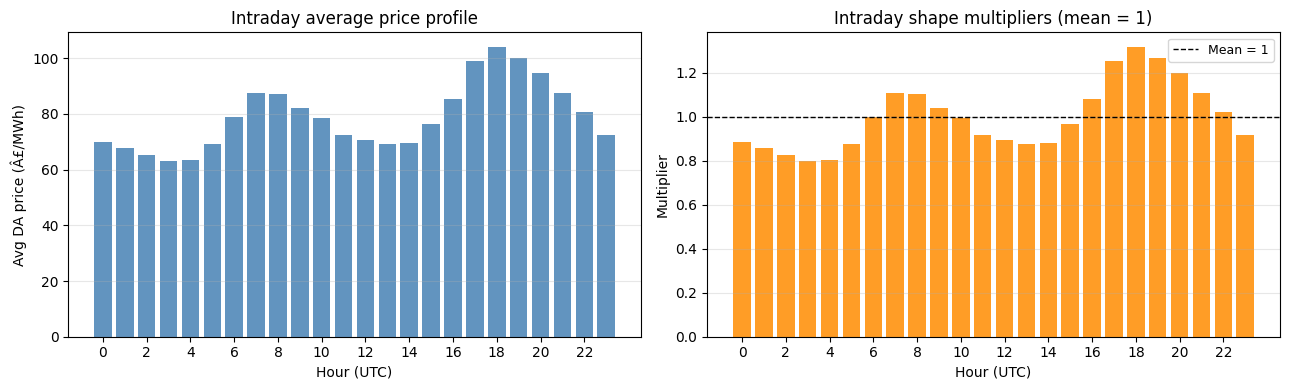

Peak hour   : 18:00  (1.318Ã—)
Trough hour : 03:00  (0.801Ã—)
Peak/trough ratio: 1.65


In [4]:
# --- 2a  Intraday profile ---
# Average price by hour across all historical days.
# We average over two settlement periods per hour; negative prices are included
# as they are genuine market outcomes that shape battery dispatch.

hourly_avg   = da.groupby("hour")["price_gbp_mwh"].mean()
intraday_mult= hourly_avg / hourly_avg.mean()   # normalised: mean = 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(hourly_avg.index, hourly_avg.values, color="steelblue", alpha=0.85)
ax.set(xlabel="Hour (UTC)", ylabel="Avg DA price (Â£/MWh)",
       title="Intraday average price profile", xticks=range(0, 24, 2))
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(intraday_mult.index, intraday_mult.values, color="darkorange", alpha=0.85)
ax.axhline(1.0, color="black", lw=1, ls="--", label="Mean = 1")
ax.set(xlabel="Hour (UTC)", ylabel="Multiplier",
       title="Intraday shape multipliers (mean = 1)", xticks=range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROC / "hpfc_intraday_profile.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Peak hour   : {intraday_mult.idxmax():02d}:00  ({intraday_mult.max():.3f}Ã—)")
print(f"Trough hour : {intraday_mult.idxmin():02d}:00  ({intraday_mult.min():.3f}Ã—)")
print(f"Peak/trough ratio: {intraday_mult.max()/intraday_mult.min():.2f}")

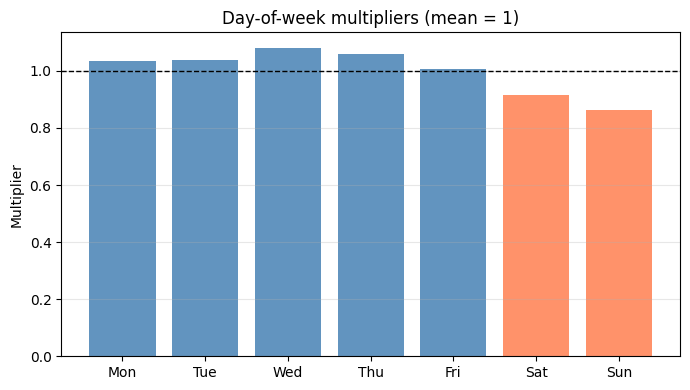

  Mon: 1.0331
  Tue: 1.0392
  Wed: 1.0811
  Thu: 1.0605
  Fri: 1.0082
  Sat: 0.9162
  Sun: 0.8617


In [5]:
# --- 2b  Day-of-week effect ---
# Compute daily average first, then mean by dow to avoid hours
# with more observations biasing the result.

daily_avg  = da.groupby(["settlement_date", "dow"])["price_gbp_mwh"].mean().reset_index()
dow_avg    = daily_avg.groupby("dow")["price_gbp_mwh"].mean()
dow_mult   = dow_avg / dow_avg.mean()

colors = ["steelblue"] * 5 + ["coral"] * 2
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(7), dow_mult.values, color=colors, alpha=0.85)
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.set(xticks=range(7), xticklabels=DOW_NAMES,
       ylabel="Multiplier", title="Day-of-week multipliers (mean = 1)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROC / "hpfc_dow_multipliers.png", dpi=120, bbox_inches="tight")
plt.show()

for i, v in dow_mult.items():
    print(f"  {DOW_NAMES[i]}: {v:.4f}")

## 3  Combined (hour Ã— day-of-week) multiplier matrix

For each of the 24 Ã— 7 = 168 cells compute the historical mean price,
then divide by the grand mean.  The result is a multiplier table with
overall grand mean = 1 that captures the joint intraday + day-of-week shape.

Historical grand mean : Â£78.97/MWh
Multiplier matrix     : (24, 7)  (hours Ã— days)
Grand mean of matrix  : 1.000000  (= 1 by construction)
Range                 : 0.710 â€“ 1.461


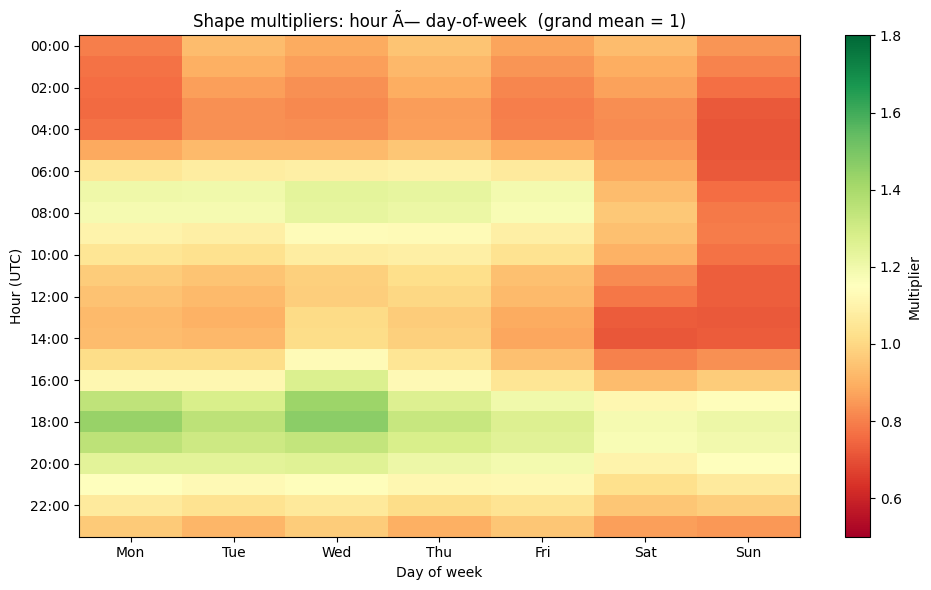

In [6]:
# Cell means: avg price for each (hour, dow) pair
cell_means = da.groupby(["hour", "dow"])["price_gbp_mwh"].mean().unstack()   # shape (24, 7)
cell_means.columns = DOW_NAMES

# Normalise so grand mean of the 168-cell matrix = 1
grand_mean_hist = float(cell_means.values.mean())
raw_mult = cell_means / grand_mean_hist

print(f"Historical grand mean : Â£{grand_mean_hist:.2f}/MWh")
print(f"Multiplier matrix     : {raw_mult.shape}  (hours Ã— days)")
print(f"Grand mean of matrix  : {raw_mult.values.mean():.6f}  (= 1 by construction)")
print(f"Range                 : {raw_mult.values.min():.3f} â€“ {raw_mult.values.max():.3f}")

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(raw_mult.values, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.8)
plt.colorbar(im, ax=ax, label="Multiplier")
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_NAMES)
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set(title="Shape multipliers: hour Ã— day-of-week  (grand mean = 1)",
       xlabel="Day of week", ylabel="Hour (UTC)")
plt.tight_layout()
plt.savefig(DATA_PROC / "hpfc_shape_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
# Print the full multiplier table
print(raw_mult.round(3).to_string())

        Mon    Tue    Wed    Thu    Fri    Sat    Sun
hour                                                 
0     0.797  0.930  0.891  0.951  0.873  0.928  0.842
1     0.773  0.899  0.862  0.920  0.845  0.894  0.809
2     0.763  0.862  0.833  0.895  0.814  0.866  0.764
3     0.757  0.832  0.816  0.861  0.795  0.826  0.721
4     0.771  0.835  0.828  0.865  0.800  0.824  0.712
5     0.886  0.925  0.923  0.953  0.892  0.847  0.710
6     1.053  1.075  1.088  1.097  1.066  0.883  0.721
7     1.204  1.201  1.241  1.229  1.189  0.931  0.760
8     1.181  1.180  1.228  1.212  1.171  0.960  0.789
9     1.104  1.085  1.135  1.133  1.086  0.939  0.794
10    1.048  1.033  1.076  1.086  1.037  0.901  0.774
11    0.969  0.949  0.978  1.021  0.937  0.822  0.730
12    0.945  0.923  0.974  0.999  0.925  0.779  0.729
13    0.922  0.903  1.008  0.969  0.889  0.728  0.719
14    0.927  0.918  1.015  0.978  0.878  0.714  0.728
15    1.016  1.015  1.132  1.046  0.939  0.803  0.835
16    1.118  1.115  1.268  1

## 4  Calendar-adjusted multipliers per delivery month

The grand mean of `raw_mult` is 1, but the actual calendar-weighted mean over a
specific delivery month differs because months have different weekday/weekend mixes.
We rescale per month so that `mean(HPFC over month) = monthly forward price`.

In [8]:
def calendar_weighted_mean(year: int, month: int, mult: pd.DataFrame) -> float:
    """
    Average of `mult` over every (hour, dow) pair that falls in the given calendar month.
    mult: DataFrame indexed by hour (0-23), columns = DOW_NAMES.
    Returns the float that, when divided into mult, gives effective multipliers
    whose calendar-weighted average equals 1 for this specific month.
    """
    start = pd.Timestamp(year=year, month=month, day=1)
    end   = start + pd.offsets.MonthEnd(0)
    total, count = 0.0, 0
    for d in pd.date_range(start, end, freq="D"):
        col    = DOW_NAMES[d.dayofweek]
        total += float(mult[col].sum())  # sum over 24 hours
        count += 24
    return total / count


# Verify for upcoming months
print("Calendar-weighted mean of raw_mult (should differ slightly from 1.0):")
for y, m in [(2026, 4), (2026, 5), (2026, 12), (2027, 1), (2027, 2)]:
    cm = calendar_weighted_mean(y, m, raw_mult)
    print(f"  {y}-{m:02d}: {cm:.5f}")

Calendar-weighted mean of raw_mult (should differ slightly from 1.0):
  2026-04: 1.00472
  2026-05: 0.99311
  2026-12: 1.00583
  2027-01: 0.99311
  2027-02: 1.00000


## 5  Build the hourly forward curve

In [9]:
rows = []
for _, frow in fwd.iterrows():
    start  = frow["delivery_start"]
    end    = frow["delivery_end"]
    F_m    = float(frow["price_gbp_mwh"])
    cal_mean = calendar_weighted_mean(start.year, start.month, raw_mult)

    for d in pd.date_range(start, end, freq="D"):
        col = DOW_NAMES[d.dayofweek]
        for h in range(24):
            mult_adj = float(raw_mult.loc[h, col]) / cal_mean   # calendar-normalised
            rows.append({
                "delivery_date"       : d,
                "hour"                : h,
                "dow"                 : d.dayofweek,
                "delivery_month"      : start.strftime("%Y-%m"),
                "monthly_fwd_gbp_mwh" : F_m,
                "multiplier"          : mult_adj,
                "price_gbp_mwh"       : F_m * mult_adj,
            })

hpfc = pd.DataFrame(rows)

print(f"HPFC built : {len(hpfc):,} rows")
print(f"Delivery   : {hpfc['delivery_date'].min().date()} â†’ {hpfc['delivery_date'].max().date()}")
print(f"Price range: Â£{hpfc['price_gbp_mwh'].min():.1f} â€“ Â£{hpfc['price_gbp_mwh'].max():.1f}/MWh")

HPFC built : 26,304 rows
Delivery   : 2026-04-01 â†’ 2029-03-31


Price range: Â£40.5 â€“ Â£147.9/MWh


In [10]:
# --- Calibration check: monthly average must equal forward price ---
check = (
    hpfc.groupby("delivery_month")
    .agg(hpfc_mean=("price_gbp_mwh", "mean"),
         fwd_price=("monthly_fwd_gbp_mwh", "first"))
    .reset_index()
)
check["error_pct"] = (check["hpfc_mean"] - check["fwd_price"]) / check["fwd_price"] * 100

max_abs_err = (check["hpfc_mean"] - check["fwd_price"]).abs().max()
print(f"Max |HPFC mean âˆ’ forward price| = Â£{max_abs_err:.6f}/MWh")

print()
print(check.head(12).to_string(index=False))

Max |HPFC mean âˆ’ forward price| = Â£0.000000/MWh

delivery_month  hpfc_mean  fwd_price     error_pct
       2026-04     101.71     101.71 -4.191580e-14
       2026-05      99.60      99.60  0.000000e+00
       2026-06      96.14      96.14 -1.478142e-14
       2026-07      95.26      95.26 -2.983593e-14
       2026-08      95.44      95.44  0.000000e+00
       2026-09      96.32      96.32  0.000000e+00
       2026-10      93.89      93.89  0.000000e+00
       2026-11      94.85      94.85 -2.996490e-14
       2026-12      96.25      96.25  0.000000e+00
       2027-01      95.52      95.52 -1.487736e-14
       2027-02      96.20      96.20 -2.954440e-14
       2027-03      92.98      92.98 -3.056755e-14


## 6  Validate against peak forward prices

UK N2EX peak: 08:00â€“20:00 Monâ€“Fri.  The HPFC-implied peak price should
be close to the market peak forward; any gap reflects that the historical
peak/off-peak ratio differs from what the market expects.

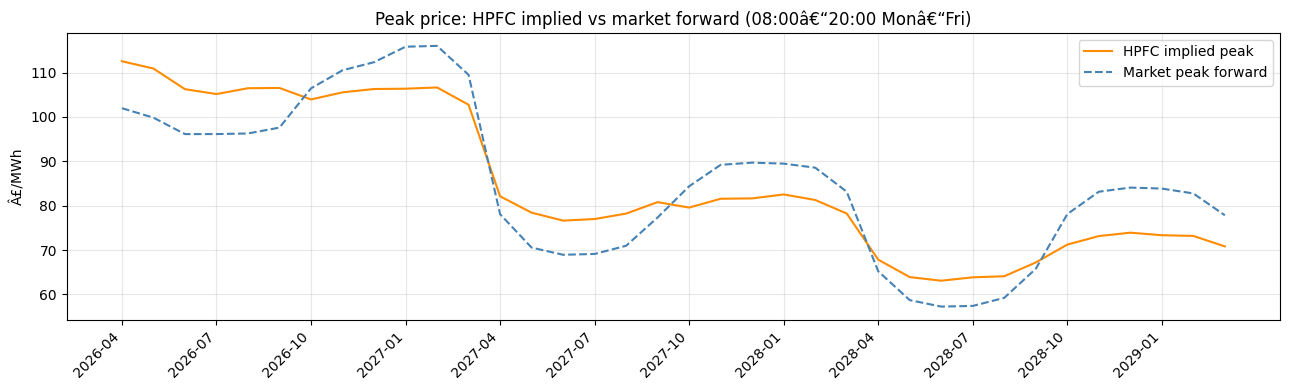

Avg peak bias (HPFC âˆ’ market): Â£-0.23/MWh
Historical peak/off-peak ratio:


  Peak    : Â£87.55/MWh
  Off-peak: Â£74.22/MWh
  Ratio   : 1.180


In [11]:
# Implied peak from HPFC
peak_mask   = hpfc["hour"].isin(PEAK_HOURS) & hpfc["dow"].isin(PEAK_DOWS)
implied_peak = (
    hpfc[peak_mask]
    .groupby("delivery_month")["price_gbp_mwh"]
    .mean()
    .reset_index()
    .rename(columns={"price_gbp_mwh": "implied_peak"})
)

fwd_peak_lkp = fwd_peak.copy()
fwd_peak_lkp["delivery_month"] = fwd_peak_lkp["delivery_start"].dt.strftime("%Y-%m")
cmp = implied_peak.merge(
    fwd_peak_lkp[["delivery_month", "price_gbp_mwh"]].rename(columns={"price_gbp_mwh": "mkt_peak"}),
    on="delivery_month", how="left",
)
cmp["peak_bias"] = cmp["implied_peak"] - cmp["mkt_peak"]

fig, ax = plt.subplots(figsize=(13, 4))
x = range(len(cmp))
ax.plot(x, cmp["implied_peak"], label="HPFC implied peak",  color="darkorange", lw=1.5)
ax.plot(x, cmp["mkt_peak"],     label="Market peak forward",color="steelblue",  lw=1.5, ls="--")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels(cmp["delivery_month"].iloc[::3], rotation=45, ha="right")
ax.set(ylabel="Â£/MWh", title="Peak price: HPFC implied vs market forward (08:00â€“20:00 Monâ€“Fri)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROC / "hpfc_peak_validation.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Avg peak bias (HPFC âˆ’ market): Â£{cmp['peak_bias'].mean():.2f}/MWh")
print(f"Historical peak/off-peak ratio:")
peak_hist    = da[da["hour"].isin(PEAK_HOURS) & da["dow"].isin(PEAK_DOWS)]["price_gbp_mwh"].mean()
offpeak_hist = da[~(da["hour"].isin(PEAK_HOURS) & da["dow"].isin(PEAK_DOWS))]["price_gbp_mwh"].mean()
print(f"  Peak    : Â£{peak_hist:.2f}/MWh")
print(f"  Off-peak: Â£{offpeak_hist:.2f}/MWh")
print(f"  Ratio   : {peak_hist / offpeak_hist:.3f}")

## 7  Save outputs

In [12]:
# --- Shape multipliers (long format) ---
mult_long = (
    raw_mult
    .reset_index()
    .melt(id_vars="hour", var_name="dow_name", value_name="multiplier")
)
mult_long["dow"] = mult_long["dow_name"].map({n: i for i, n in enumerate(DOW_NAMES)})
mult_long = mult_long[["hour", "dow", "dow_name", "multiplier"]].sort_values(["dow", "hour"])
mult_long.to_parquet(DATA_PROC / "shape_multipliers.parquet", index=False)
print(f"shape_multipliers.parquet : {len(mult_long)} rows  (grand mean = {mult_long['multiplier'].mean():.6f})")

# --- HPFC ---
hpfc.to_parquet(DATA_PROC / "hpfc.parquet", index=False)
print(f"hpfc.parquet              : {len(hpfc):,} rows")

# --- Multiplier matrix as JSON (for simulation / quick look-up) ---
hpfc_params = {
    "raw_mult": raw_mult.values.tolist(),          # list[24][7]
    "hours"   : list(range(24)),
    "dow_names": DOW_NAMES,
    "grand_mean_hist_gbp_mwh": grand_mean_hist,
    "as_of_date" : str(AS_OF.date()),
    "data_start" : str(da["settlement_date"].min().date()),
    "data_end"   : str(da["settlement_date"].max().date()),
    "n_obs"      : int(len(da)),
    "peak_hours" : PEAK_HOURS,
    "peak_dows"  : PEAK_DOWS,
    "peak_ofp_ratio_hist": round(peak_hist / offpeak_hist, 4),
}
with open(DATA_PROC / "hpfc_params.json", "w") as f:
    json.dump(hpfc_params, f, indent=2)
print("hpfc_params.json          : saved")

shape_multipliers.parquet : 168 rows  (grand mean = 1.000000)
hpfc.parquet              : 26,304 rows
hpfc_params.json          : saved


## 8  Summary visualisations

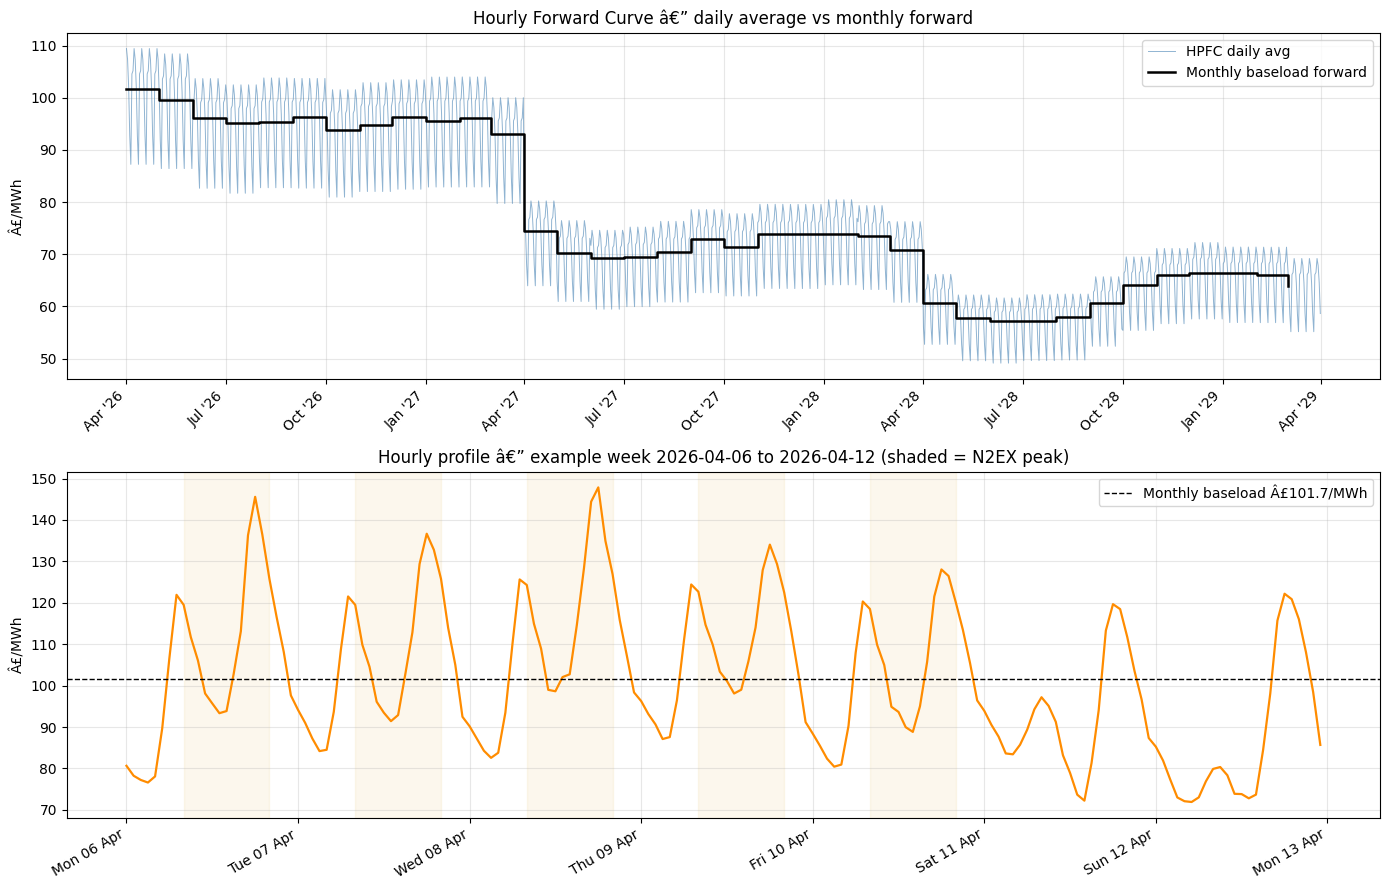

In [13]:
# --- Full curve: daily average vs monthly forward ---
daily_hpfc = hpfc.groupby("delivery_date")["price_gbp_mwh"].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(daily_hpfc.index, daily_hpfc.values,
        lw=0.7, color="steelblue", alpha=0.6, label="HPFC daily avg")
ax.step(fwd["delivery_start"], fwd["price_gbp_mwh"],
        where="post", color="black", lw=1.8, label="Monthly baseload forward")
ax.set(ylabel="Â£/MWh", title="Hourly Forward Curve â€” daily average vs monthly forward")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# --- Example week: first full Monâ€“Sun week in the curve ---
first_mon = hpfc.loc[hpfc["dow"] == 0, "delivery_date"].iloc[0]
week_end  = first_mon + pd.Timedelta(days=6)
week      = hpfc[(hpfc["delivery_date"] >= first_mon) & (hpfc["delivery_date"] <= week_end)].copy()
week["dt"] = pd.to_datetime(week["delivery_date"]) + pd.to_timedelta(week["hour"], unit="h")

ax = axes[1]
ax.plot(week["dt"], week["price_gbp_mwh"], lw=1.6, color="darkorange")
ax.axhline(week["monthly_fwd_gbp_mwh"].iloc[0], color="black", ls="--", lw=1,
           label=f"Monthly baseload Â£{week['monthly_fwd_gbp_mwh'].iloc[0]:.1f}/MWh")
# shade peak hours Monâ€“Fri
for d in pd.date_range(first_mon, week_end, freq="D"):
    if d.dayofweek < 5:
        ax.axvspan(d + pd.Timedelta(hours=8), d + pd.Timedelta(hours=20),
                   alpha=0.08, color="goldenrod")
ax.set(ylabel="Â£/MWh",
       title=f"Hourly profile â€” example week {first_mon.date()} to {week_end.date()} (shaded = N2EX peak)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(DATA_PROC / "hpfc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
# --- Multiplier summary table ---
print("=" * 60)
print("SHAPE MULTIPLIER SUMMARY")
print("=" * 60)
print()
print("Intraday multipliers (all-day average):")
for h, v in intraday_mult.items():
    bar = "â–ˆ" * int(v * 20)
    print(f"  {h:02d}:00  {v:.3f}  {bar}")

print()
print("Day-of-week multipliers:")
for i, v in dow_mult.items():
    print(f"  {DOW_NAMES[i]}  {v:.4f}")

print()
print(f"Peak/off-peak ratio (historical, 08-20 Mon-Fri): {peak_hist/offpeak_hist:.3f}")
print(f"Max intraday multiplier : {raw_mult.values.max():.3f}")
print(f"Min intraday multiplier : {raw_mult.values.min():.3f}")
print()
print("Outputs written:")
print("  data/processed/shape_multipliers.parquet")
print("  data/processed/hpfc.parquet")
print("  data/processed/hpfc_params.json")

SHAPE MULTIPLIER SUMMARY

Intraday multipliers (all-day average):
  00:00  0.887  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  01:00  0.857  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  02:00  0.828  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  03:00  0.801  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  04:00  0.805  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  05:00  0.877  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  06:00  0.998  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  07:00  1.108  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  08:00  1.103  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  09:00  1.040  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  10:00  0.994  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  11:00  0.915  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  12:00  0.897  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
  13:

## 9  BESS Valuation on HPFC

Perfect-foresight LP dispatch day-by-day over the HPFC horizon.
Each day: solve a 24-hour LP to find the optimal charge/discharge schedule,
then accumulate revenue and compute an annualised P&L.

**P&L components** (per year):
- **Gross revenue**: LP dispatch × hourly forward price × availability
- **VOM**: variable O&M on throughput
- **Optimiser fee**: % of net-of-VOM revenue
- **FOM**: fixed O&M (£/kW/yr × capacity)
- **Net P&L**: gross − VOM − optimiser fee − FOM

In [15]:
# ── Configurable parameters ───────────────────────────────────────────────
VALUATION_DURATION_H = 2.0   # battery duration in hours: 1, 2, or 4
HORIZON_YEARS        = 5     # forecast horizon (years from today)
APPLY_MARKET_DECAY   = True  # apply FINANCE['revenue_decay_per_year'] each year
# ──────────────────────────────────────────────────────────────────────

In [16]:
import sys, copy
sys.path.insert(0, '../src')
from config import ASSET as _ASSET_BASE, configure_asset_duration, FINANCE

ASSET_VAL = copy.deepcopy(_ASSET_BASE)
configure_asset_duration(ASSET_VAL, VALUATION_DURATION_H)

print(f"Battery : {ASSET_VAL['power_mw']:.0f} MW / {ASSET_VAL['energy_mwh']:.0f} MWh  "
      f"({VALUATION_DURATION_H:.0f}h duration)")
print(f"SoC     : {ASSET_VAL['soc_min_mwh']:.0f}–{ASSET_VAL['soc_max_mwh']:.0f} MWh  "
      f"(init {ASSET_VAL['soc_init_mwh']:.0f} MWh)")
print(f"RTE     : {ASSET_VAL['rte']*100:.0f}%  (eta = {ASSET_VAL['eta_charge']:.4f})")
print(f"VOM     : £{ASSET_VAL['vom_gbp_mwh']:.2f}/MWh")
print(f"FOM     : £{ASSET_VAL['fom_gbp_kw_yr']:.1f}/kW/yr  "
      f"→ £{ASSET_VAL['fom_gbp_kw_yr']*ASSET_VAL['power_mw']*1000/1e6:.2f}M/yr")
print(f"Optim   : {ASSET_VAL['optimiser_fee_frac']*100:.0f}% of net-of-VOM revenue")
print(f"Avail   : {ASSET_VAL['availability']*100:.0f}%")
print(f"Decay   : {FINANCE['revenue_decay_per_year']*100:.1f}%/yr  (applied: {APPLY_MARKET_DECAY})")

Battery : 100 MW / 200 MWh  (2h duration)
SoC     : 20–180 MWh  (init 100 MWh)
RTE     : 88%  (eta = 0.9381)
VOM     : £1.20/MWh
FOM     : £8.0/kW/yr  → £0.80M/yr
Optim   : 12% of net-of-VOM revenue
Avail   : 96%
Decay   : 1.5%/yr  (applied: True)


In [17]:
TODAY        = pd.Timestamp('today').normalize()
HORIZON_END  = TODAY + pd.DateOffset(years=HORIZON_YEARS)

# Filter HPFC to dates from today onwards
hpfc_fut  = hpfc[hpfc['delivery_date'] >= TODAY].copy()
hpfc_cov  = hpfc_fut['delivery_date'].max()   # last day covered by forward curve

print(f"Today           : {TODAY.date()}")
print(f"Forward curve to: {hpfc_cov.date()}")
print(f"Horizon end     : {HORIZON_END.date()}")

gap_days = max(0, (HORIZON_END - hpfc_cov).days - 1)
print(f"Extension needed: {gap_days} days")

if gap_days > 0:
    # Flat extension: trailing 12-month average of monthly forward prices
    trailing_start = hpfc_cov - pd.DateOffset(months=12)
    flat_px = float(
        hpfc_fut[hpfc_fut['delivery_date'] >= trailing_start]['monthly_fwd_gbp_mwh'].mean()
    )
    print(f"Flat extension  : £{flat_px:.2f}/MWh  (12m trailing avg of fwd prices)")

    ext_rows = []
    for d in pd.date_range(hpfc_cov + pd.Timedelta(days=1), HORIZON_END, freq='D'):
        cm  = calendar_weighted_mean(d.year, d.month, raw_mult)
        col = DOW_NAMES[d.dayofweek]
        for h in range(24):
            m = float(raw_mult.loc[h, col]) / cm
            ext_rows.append({
                'delivery_date':        d,
                'hour':                 h,
                'dow':                  d.dayofweek,
                'delivery_month':       d.strftime('%Y-%m'),
                'monthly_fwd_gbp_mwh':  flat_px,
                'multiplier':           m,
                'price_gbp_mwh':        flat_px * m,
            })
    hpfc_full = pd.concat([hpfc_fut, pd.DataFrame(ext_rows)], ignore_index=True)
else:
    hpfc_full = hpfc_fut[hpfc_fut['delivery_date'] <= HORIZON_END].copy()

hpfc_full = hpfc_full.sort_values(['delivery_date', 'hour']).reset_index(drop=True)
print(f"\nFull horizon    : {hpfc_full['delivery_date'].nunique()} days  "
      f"(from curve: {int((hpfc_cov - TODAY).days)+1} | extended: {gap_days})")

Today           : 2026-04-30
Forward curve to: 2029-03-31
Horizon end     : 2031-04-30
Extension needed: 759 days
Flat extension  : £62.05/MWh  (12m trailing avg of fwd prices)



Full horizon    : 1827 days  (from curve: 1067 | extended: 759)


In [18]:
from optimisation.rolling_intrinsic import solve_daily_lp

P_bar  = float(ASSET_VAL['power_mw'])
E_nm   = float(ASSET_VAL['energy_mwh'])
eta_c  = float(ASSET_VAL['eta_charge'])
eta_d  = float(ASSET_VAL['eta_discharge'])
E_min  = float(ASSET_VAL['soc_min_mwh'])
E_max  = float(ASSET_VAL['soc_max_mwh'])
vom    = float(ASSET_VAL['vom_gbp_mwh'])
avail  = float(ASSET_VAL['availability'])
dt_h   = 1.0   # hourly prices -> 1-hour time-step

dispatch_rows = []
E_t = float(ASSET_VAL['soc_init_mwh'])

for d, grp in hpfc_full.groupby('delivery_date'):
    prices = grp.sort_values('hour')['price_gbp_mwh'].values
    if len(prices) < 24:
        continue

    d_opt, c_opt, gross_rev = solve_daily_lp(
        prices, E_t, E_min, E_max, P_bar, eta_c, eta_d, dt_h=dt_h
    )

    # Availability scales revenue; SoC evolves at full dispatch (conservative)
    gross_adj = gross_rev * avail
    vom_cost  = float((d_opt + c_opt).sum() * dt_h * vom) * avail
    E_t       = float(
        np.clip(E_t + (c_opt * eta_c - d_opt / eta_d).sum() * dt_h, E_min, E_max)
    )

    dispatch_rows.append({
        'date':              pd.Timestamp(d),
        'gross_revenue_gbp': gross_adj,
        'vom_cost_gbp':      vom_cost,
        'discharge_mwh':     float(d_opt.sum() * dt_h) * avail,
        'charge_mwh':        float(c_opt.sum() * dt_h) * avail,
        'cycles_equiv':      float(d_opt.sum() * dt_h / E_nm) * avail,
        'soc_end_mwh':       E_t,
        'in_fwd_window':     pd.Timestamp(d) <= hpfc_cov,
    })

dispatch = pd.DataFrame(dispatch_rows)
print(f"Dispatched      : {len(dispatch):,} days")
print(f"Total gross rev : £{dispatch['gross_revenue_gbp'].sum()/1e6:.2f}M")
print(f"Total VOM       : £{dispatch['vom_cost_gbp'].sum()/1e6:.2f}M")
print(f"Total cycles    : {dispatch['cycles_equiv'].sum():.0f}  "
      f"(avg {dispatch['cycles_equiv'].sum()/HORIZON_YEARS:.0f}/yr)")

Dispatched      : 1,827 days
Total gross rev : £9.62M
Total VOM       : £1.25M
Total cycles    : 2445  (avg 489/yr)


In [19]:
decay      = float(FINANCE['revenue_decay_per_year'])
fom_yr     = ASSET_VAL['fom_gbp_kw_yr'] * ASSET_VAL['power_mw'] * 1_000   # GBP/yr
optim_fee  = float(ASSET_VAL['optimiser_fee_frac'])

# Decay factor: revenues shrink (1-decay)^years from today
dispatch['years_elapsed'] = (dispatch['date'] - TODAY).dt.days / 365.25
dispatch['decay_factor']  = (
    (1 - decay) ** dispatch['years_elapsed'] if APPLY_MARKET_DECAY else 1.0
)

dispatch['gross_adj']  = dispatch['gross_revenue_gbp'] * dispatch['decay_factor']
dispatch['vom_adj']    = dispatch['vom_cost_gbp']      * dispatch['decay_factor']
dispatch['net_of_vom'] = dispatch['gross_adj'] - dispatch['vom_adj']

# Daily net P&L (kept for cumulative chart)
dispatch['daily_after_optim'] = dispatch['net_of_vom'] * (1 - optim_fee)
dispatch['daily_net_pl']      = dispatch['daily_after_optim'] - fom_yr / 365.25

# Build annual summary
annual_rows = []
for yr in range(HORIZON_YEARS):
    yr_start = TODAY + pd.DateOffset(years=yr)
    yr_end   = TODAY + pd.DateOffset(years=yr + 1) - pd.Timedelta(days=1)
    sub      = dispatch[(dispatch['date'] >= yr_start) & (dispatch['date'] <= yr_end)]
    n_days   = len(sub)

    gross  = sub['gross_adj'].sum()
    vom_c  = sub['vom_adj'].sum()
    nov    = gross - vom_c
    opt_c  = nov * optim_fee
    fom_c  = fom_yr * n_days / 365.25
    net_pl = nov - opt_c - fom_c

    annual_rows.append({
        'year':         yr + 1,
        'label':        f'Y{yr+1}',
        'yr_start':     yr_start,
        'n_days':       n_days,
        'gross_m':      gross   / 1e6,
        'vom_m':        vom_c   / 1e6,
        'optim_m':      opt_c   / 1e6,
        'fom_m':        fom_c   / 1e6,
        'net_pl_m':     net_pl  / 1e6,
        'net_per_mw_k': net_pl  / ASSET_VAL['power_mw'] / 1e3,
        'cycles':       sub['cycles_equiv'].sum(),
        'in_fwd':       bool(sub['in_fwd_window'].all()),
    })

annual_df = pd.DataFrame(annual_rows)

print(f"Annual gross P&L ({VALUATION_DURATION_H:.0f}h BESS, {ASSET_VAL['power_mw']:.0f} MW)")
print(annual_df[['label','n_days','gross_m','vom_m','optim_m','fom_m','cycles']].to_string(index=False))
print()
print(f"5yr total gross : £{annual_df['gross_m'].sum():.2f}M")
print(f"Annualised gross: £{annual_df['gross_m'].mean():.2f}M/yr  "
      f"(£{annual_df['gross_m'].mean()*1e6/ASSET_VAL['power_mw']/1e3:.0f}k/MW/yr)")
print(f"CAPEX           : £{ASSET_VAL['capex_gbp']/1e6:.1f}M  (£{ASSET_VAL['capex_gbp_kwh']:.0f}/kWh)")
print(f"Gross / CAPEX   : {annual_df['gross_m'].mean()*1e6/ASSET_VAL['capex_gbp']*100:.1f}%/yr")


Annual gross P&L (2h BESS, 100 MW)
label  n_days  gross_m    vom_m  optim_m    fom_m     cycles
   Y1     365 2.557689 0.248473 0.277106 0.799452 488.472422
   Y2     366 1.901884 0.245561 0.198759 0.801643 489.913344
   Y3     365 1.634517 0.240810 0.167245 0.799452 487.751962
   Y4     365 1.610770 0.237552 0.164786 0.799452 488.472422
   Y5     365 1.585250 0.233991 0.162151 0.799452 488.472422

5yr total gross : £9.29M
Annualised gross: £1.86M/yr  (£19k/MW/yr)
CAPEX           : £44.0M  (£220/kWh)
Gross / CAPEX   : 4.2%/yr


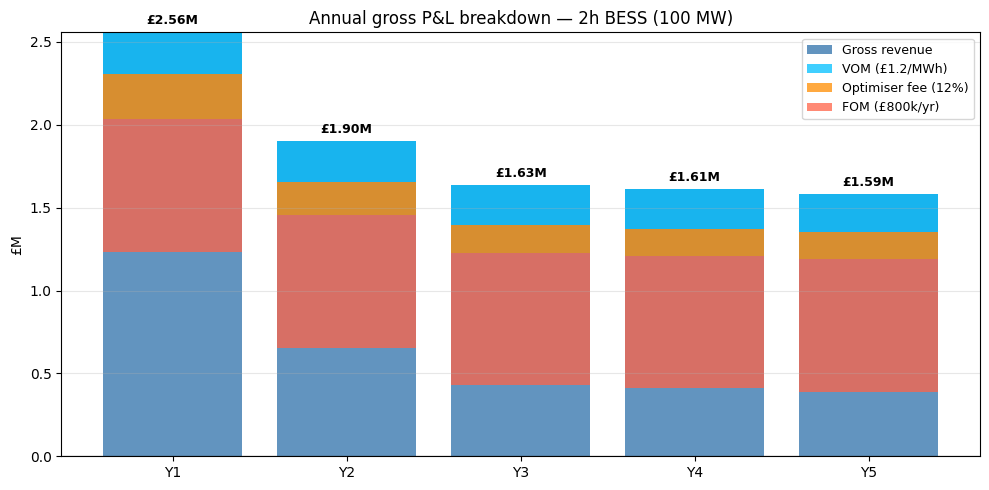

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(annual_df))
labels = annual_df['label'].values

ax.bar(x, annual_df['gross_m'], color='steelblue', alpha=0.85, label='Gross revenue')
tops = annual_df['gross_m'].values.copy()
for col, clr, lbl in [
    ('vom_m',   'deepskyblue', f'VOM (£{vom:.1f}/MWh)'),
    ('optim_m', 'darkorange',  f'Optimiser fee ({optim_fee*100:.0f}%)'),
    ('fom_m',   'tomato',      f'FOM (£{fom_yr/1e3:.0f}k/yr)'),
]:
    vals = annual_df[col].values
    ax.bar(x, -vals, bottom=tops, color=clr, alpha=0.75, label=lbl)
    tops -= vals

# Label gross on top of each bar
for xi, yi in zip(x, annual_df['gross_m']):
    ax.text(xi, yi + 0.03, f'£{yi:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set(xticks=x, xticklabels=labels, ylabel='£M',
       title=f'Annual gross P&L breakdown — {VALUATION_DURATION_H:.0f}h BESS ({ASSET_VAL["power_mw"]:.0f} MW)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROC / 'hpfc_valuation_annual_pl.png', dpi=120, bbox_inches='tight')
plt.show()


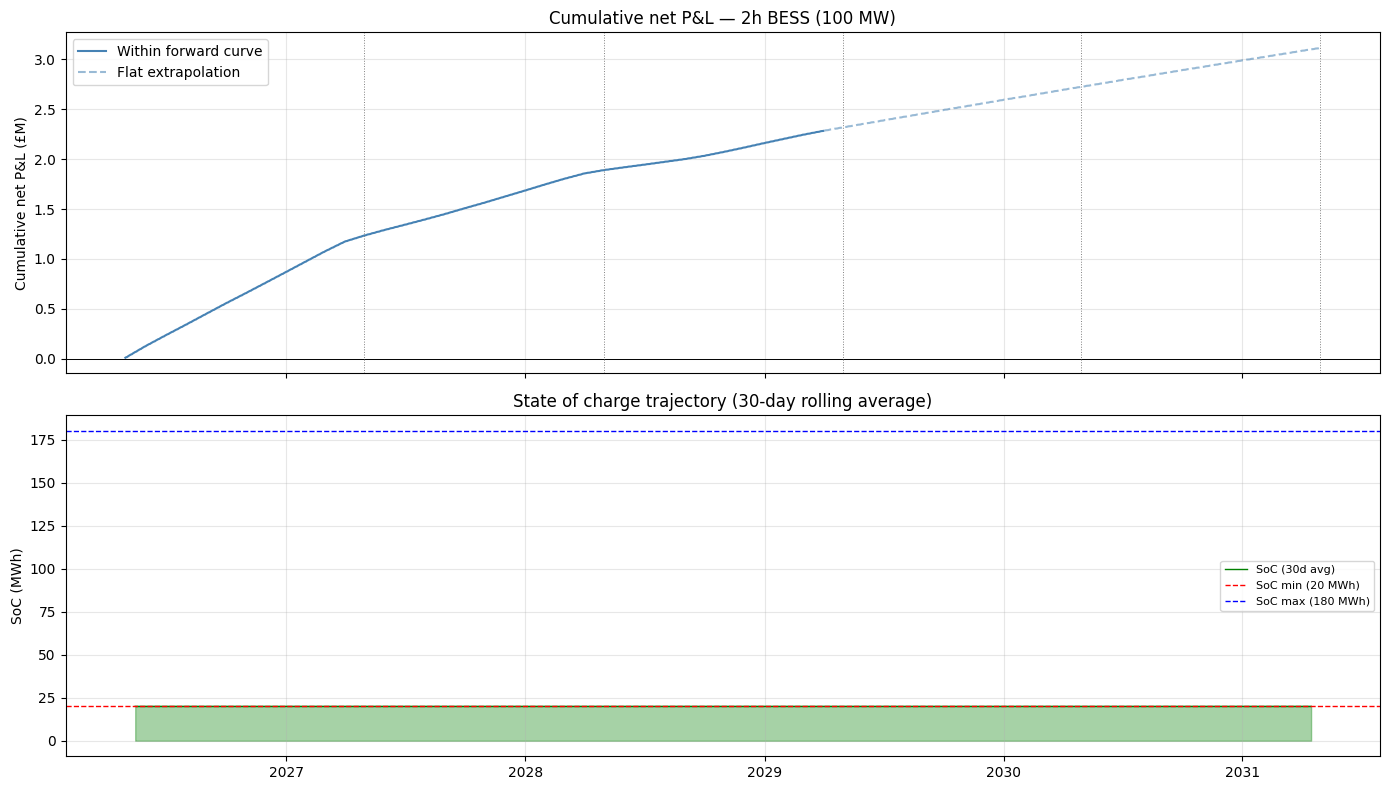

In [21]:
dispatch['cum_net_pl_m'] = dispatch['daily_net_pl'].cumsum() / 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: cumulative net P&L
ax = axes[0]
in_fwd  = dispatch['in_fwd_window']
ax.plot(dispatch.loc[in_fwd,  'date'], dispatch.loc[in_fwd,  'cum_net_pl_m'],
        color='steelblue', lw=1.5, label='Within forward curve')
ax.plot(dispatch.loc[~in_fwd, 'date'], dispatch.loc[~in_fwd, 'cum_net_pl_m'],
        color='steelblue', lw=1.5, ls='--', alpha=0.55, label='Flat extrapolation')
ax.axhline(0, color='black', lw=0.7)
for yr in range(1, HORIZON_YEARS + 1):
    ax.axvline(TODAY + pd.DateOffset(years=yr), color='gray', lw=0.7, ls=':')
ax.set(ylabel='Cumulative net P&L (£M)',
       title=f"Cumulative net P&L — {VALUATION_DURATION_H:.0f}h BESS ({ASSET_VAL['power_mw']:.0f} MW)")
ax.legend()
ax.grid(alpha=0.3)

# Bottom: SoC (30-day rolling average)
soc_roll = dispatch.set_index('date')['soc_end_mwh'].rolling(30, center=True).mean()
ax = axes[1]
ax.fill_between(soc_roll.index, soc_roll.values, alpha=0.35, color='green')
ax.plot(soc_roll.index, soc_roll.values, color='green', lw=1, label='SoC (30d avg)')
ax.axhline(ASSET_VAL['soc_min_mwh'], color='red',  lw=1, ls='--',
           label=f"SoC min ({ASSET_VAL['soc_min_mwh']:.0f} MWh)")
ax.axhline(ASSET_VAL['soc_max_mwh'], color='blue', lw=1, ls='--',
           label=f"SoC max ({ASSET_VAL['soc_max_mwh']:.0f} MWh)")
ax.set(ylabel='SoC (MWh)', title='State of charge trajectory (30-day rolling average)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(DATA_PROC / 'hpfc_valuation_cumulative.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
print('=' * 60)
print(f"BESS VALUATION SUMMARY — HPFC perfect-foresight dispatch")
print(f"Asset  : {ASSET_VAL['power_mw']:.0f} MW / {ASSET_VAL['energy_mwh']:.0f} MWh  ({VALUATION_DURATION_H:.0f}h)")
print(f"Curve  : {AS_OF.date()}  |  Horizon: {HORIZON_YEARS}yr from {TODAY.date()}")
print(f"Decay  : {FINANCE['revenue_decay_per_year']*100:.1f}%/yr  (applied: {APPLY_MARKET_DECAY})")
print(f"CAPEX  : £{ASSET_VAL['capex_gbp']/1e6:.1f}M  (£{ASSET_VAL['capex_gbp_kwh']:.0f}/kWh)")
print('=' * 60)
print(f"{'Year':<7}{'Days':>5}  {'Gross':>8}  {'VOM':>6}  {'OptFee':>7}  {'FOM':>6}  {'Cycles':>7}")
print(f"       {'     '}  {'£M':>8}  {'£M':>6}  {'£M':>7}  {'£M':>6}")
print('-' * 60)
for _, r in annual_df.iterrows():
    ext = '*' if not r['in_fwd'] else ' '
    print(f"{r['label']:<6}{ext}{r['n_days']:>5}  {r['gross_m']:>8.2f}  {r['vom_m']:>6.2f}  "
          f"{r['optim_m']:>7.2f}  {r['fom_m']:>6.2f}  {r['cycles']:>7.0f}")
print('-' * 60)
tot = annual_df.agg({'gross_m':'sum','vom_m':'sum','optim_m':'sum',
                     'fom_m':'sum','cycles':'sum'})
print(f"{'TOTAL':<7}{annual_df['n_days'].sum():>5}  {tot['gross_m']:>8.2f}  {tot['vom_m']:>6.2f}  "
      f"{tot['optim_m']:>7.2f}  {tot['fom_m']:>6.2f}  {tot['cycles']:>7.0f}")
print()
print(f"* = flat-extrapolated beyond forward curve ({hpfc_cov.date()})")
print()
print(f"Annualised gross    : £{annual_df['gross_m'].mean():.2f}M/yr  "
      f"(£{annual_df['gross_m'].mean()*1e6/ASSET_VAL['power_mw']/1e3:.0f}k/MW/yr)")
print(f"Gross / CAPEX       : {annual_df['gross_m'].mean()*1e6/ASSET_VAL['capex_gbp']*100:.1f}%/yr")
print(f"Avg EFC/yr          : {annual_df['cycles'].mean():.0f}  "
      f"(warranty: {ASSET_VAL['efc_per_year_warranty']} / KYOS: {ASSET_VAL['efc_per_year_kyos']})")


BESS VALUATION SUMMARY — HPFC perfect-foresight dispatch
Asset  : 100 MW / 200 MWh  (2h)
Curve  : 2026-03-06  |  Horizon: 5yr from 2026-04-30
Decay  : 1.5%/yr  (applied: True)
CAPEX  : £44.0M  (£220/kWh)
Year    Days     Gross     VOM   OptFee     FOM   Cycles
                    £M      £M       £M      £M
------------------------------------------------------------
Y1       365      2.56    0.25     0.28    0.80      488
Y2       366      1.90    0.25     0.20    0.80      490
Y3    *  365      1.63    0.24     0.17    0.80      488
Y4    *  365      1.61    0.24     0.16    0.80      488
Y5    *  365      1.59    0.23     0.16    0.80      488
------------------------------------------------------------
TOTAL   1826      9.29    1.21     0.97    4.00     2443

* = flat-extrapolated beyond forward curve (2029-03-31)

Annualised gross    : £1.86M/yr  (£19k/MW/yr)
Gross / CAPEX       : 4.2%/yr
Avg EFC/yr          : 489  (warranty: 520 / KYOS: 730)


## 10  Export dashboard JSON

Builds (or updates) `data/processed/dashboard.json` keyed by asset duration. All monetary values in kEUR/MW/yr.

In [23]:
FX_GBP_EUR = 1.18   # 1 GBP = N EUR

def to_keur_mw_yr(gbp_m):
    return round(gbp_m * 1e6 / ASSET_VAL['power_mw'] * FX_GBP_EUR / 1e3, 1)

# ── intrinsic rows from annual_df ──────────────────────────────────────────
intrinsic_rows = [
    {
        'year':   r['label'],
        'gross':  to_keur_mw_yr(r['gross_m']),
        'vom':    to_keur_mw_yr(r['vom_m']),
        'optim':  to_keur_mw_yr(r['optim_m']),
        'fom':    to_keur_mw_yr(r['fom_m']),
        'cycles': int(round(r['cycles'])),
        'in_fwd': bool(r['in_fwd']),
    }
    for _, r in annual_df.iterrows()
]

# ── LSMC total value ───────────────────────────────────────────────────────
lsmc_file = DATA_PROC / f"lsmc_valuation_summary_{int(VALUATION_DURATION_H)}h.json"
with open(lsmc_file) as f:
    lsmc_raw = json.load(f)

def lsmc_keur(field):
    return round(lsmc_raw['mtm_gbp_per_mw_year'][field] * FX_GBP_EUR / 1e3, 1)

duration_key = f"{int(VALUATION_DURATION_H)}h"

entry = {
    'as_of_date':   str(AS_OF.date()),
    'generated_at': str(TODAY.date()),
    'fx_gbp_eur':   FX_GBP_EUR,
    'unit':         'kEUR/MW/yr',
    'asset': {
        'power_mw':    ASSET_VAL['power_mw'],
        'energy_mwh':  ASSET_VAL['energy_mwh'],
        'duration_h':  VALUATION_DURATION_H,
        'capex_gbp_m': round(ASSET_VAL['capex_gbp'] / 1e6, 1),
    },
    'total_value': {
        'mean': lsmc_keur('mean'),
        'p5':   lsmc_keur('p5'),
        'p50':  lsmc_keur('p50'),
        'p95':  lsmc_keur('p95'),
        'horizon_years': round(lsmc_raw['valuation_horizon_years'], 3),
        'n_paths':       lsmc_raw['n_paths'],
    },
    'intrinsic':      intrinsic_rows,
    'decay_pct_yr':   FINANCE['revenue_decay_per_year'] * 100,
    'horizon_years':  HORIZON_YEARS,
}

# Merge into dashboard.json (preserves other duration keys)
dash_path = DATA_PROC / 'dashboard.json'
dashboard = json.loads(dash_path.read_text()) if dash_path.exists() else {}
dashboard[duration_key] = entry
dash_path.write_text(json.dumps(dashboard, indent=2))

print(f'dashboard.json updated  (key: {duration_key})')
print(f'Total value (LSMC)  mean : {entry["total_value"]["mean"]:>7.1f} kEUR/MW/yr')
print(f'                    P5   : {entry["total_value"]["p5"]:>7.1f}')
print(f'                    P95  : {entry["total_value"]["p95"]:>7.1f}')
print(f'Intrinsic Y1 gross       : {intrinsic_rows[0]["gross"]:>7.1f} kEUR/MW/yr')
print(f'Avg cycles/yr            : {sum(r["cycles"] for r in intrinsic_rows)//len(intrinsic_rows):>7}')


dashboard.json updated  (key: 2h)
Total value (LSMC)  mean :   134.0 kEUR/MW/yr
                    P5   :    65.7
                    P95  :   220.2
Intrinsic Y1 gross       :    30.2 kEUR/MW/yr
Avg cycles/yr            :     488


## 10  Export dashboard JSON

Builds (or updates) `data/processed/dashboard.json` keyed by asset duration.
All monetary values in kEUR/MW/yr.

In [24]:
FX_GBP_EUR = 1.18   # 1 GBP = N EUR

def to_keur_mw_yr(gbp_m):
    """Convert asset-level GBP millions to kEUR per MW per year."""
    return round(gbp_m * 1e6 / ASSET_VAL['power_mw'] * FX_GBP_EUR / 1e3, 1)

# Intrinsic rows from annual_df
intrinsic_rows = [
    {
        'year':   r['label'],
        'gross':  to_keur_mw_yr(r['gross_m']),
        'vom':    to_keur_mw_yr(r['vom_m']),
        'optim':  to_keur_mw_yr(r['optim_m']),
        'fom':    to_keur_mw_yr(r['fom_m']),
        'cycles': int(round(r['cycles'])),
        'in_fwd': bool(r['in_fwd']),
    }
    for _, r in annual_df.iterrows()
]

# LSMC total value
lsmc_file = DATA_PROC / f"lsmc_valuation_summary_{int(VALUATION_DURATION_H)}h.json"
with open(lsmc_file) as f_lsmc:
    lsmc_raw = json.load(f_lsmc)

def lsmc_keur(field):
    return round(lsmc_raw['mtm_gbp_per_mw_year'][field] * FX_GBP_EUR / 1e3, 1)

duration_key = f"{int(VALUATION_DURATION_H)}h"

entry = {
    'as_of_date':   str(AS_OF.date()),
    'generated_at': str(TODAY.date()),
    'fx_gbp_eur':   FX_GBP_EUR,
    'unit':         'kEUR/MW/yr',
    'asset': {
        'power_mw':    ASSET_VAL['power_mw'],
        'energy_mwh':  ASSET_VAL['energy_mwh'],
        'duration_h':  VALUATION_DURATION_H,
        'capex_gbp_m': round(ASSET_VAL['capex_gbp'] / 1e6, 1),
    },
    'total_value': {
        'mean':          lsmc_keur('mean'),
        'p5':            lsmc_keur('p5'),
        'p50':           lsmc_keur('p50'),
        'p95':           lsmc_keur('p95'),
        'horizon_years': round(lsmc_raw['valuation_horizon_years'], 3),
        'n_paths':       lsmc_raw['n_paths'],
    },
    'intrinsic':     intrinsic_rows,
    'decay_pct_yr':  FINANCE['revenue_decay_per_year'] * 100,
    'horizon_years': HORIZON_YEARS,
}

# Merge into dashboard.json (preserves other duration keys)
dash_path = DATA_PROC / 'dashboard.json'
dashboard = json.loads(dash_path.read_text()) if dash_path.exists() else {}
dashboard[duration_key] = entry
dash_path.write_text(json.dumps(dashboard, indent=2))

print(f'dashboard.json updated  (key: {duration_key})')
print(f'Total value (LSMC)  mean : {entry["total_value"]["mean"]:>7.1f} kEUR/MW/yr')
print(f'                    P5   : {entry["total_value"]["p5"]:>7.1f}')
print(f'                    P95  : {entry["total_value"]["p95"]:>7.1f}')
print(f'Intrinsic Y1 gross       : {intrinsic_rows[0]["gross"]:>7.1f} kEUR/MW/yr')
print(f'Avg cycles/yr            : {sum(r["cycles"] for r in intrinsic_rows)//len(intrinsic_rows):>7}')


dashboard.json updated  (key: 2h)
Total value (LSMC)  mean :   134.0 kEUR/MW/yr
                    P5   :    65.7
                    P95  :   220.2
Intrinsic Y1 gross       :    30.2 kEUR/MW/yr
Avg cycles/yr            :     488
